<h1> Geometric Operations and Other Mathematical Tools with OpenCV</h1>


Estimated time needed: **40** minutes


<h2> Spatial Operations in Image Processing</h2>


Spatial operations use  pixels in a neighborhood to determine the present pixel value. Applications include filtering and sharpening. They are used in many steps in computer vision like segmentation and are a key building block in Artificial Intelligence algorithms.


- Linear Filtering
    - Filtering Noise
    - Gaussian Blur
    - Image Sharpening
- Edges
- Median
- Threshold


* * *


Download the images for the lab


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/cameraman.jpeg
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/lenna.png
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-CV0101EN-SkillsNetwork/images%20/images_part_1/barbara.png   

'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.
'wget' is not recognized as an internal or external command,
operable program or batch file.


We will import the following libraries


In [ ]:
# Used to view the images
import matplotlib.pyplot as plt # thư viện matplotlib.pyplot được sử dụng để hiển thị hình ảnh
# Used to perform filtering on an image
import cv2 # thư viện OpenCV được sử dụng để thực hiện các phép lọc trên hình ảnh
# Used to create kernels for filtering
import numpy as np # thư viện NumPy được sử dụng để tạo các kernel cho việc lọc ảnh

This function will plot two images side by side 


In [ ]:
def plot_image(image_1, image_2,title_1="Orignal",title_2="New Image"): # hàm plot_image được định nghĩa để hiển thị hai hình ảnh cạnh nhau, với tiêu đề tùy chọn cho mỗi hình ảnh
    plt.figure(figsize=(10,10)) # tạo một figure có kích thước 10x10 inch để hiển thị hình ảnh
    plt.subplot(1, 2, 1) # chia figure thành 1 hàng và 2 cột, và chọn vị trí đầu tiên để hiển thị hình ảnh đầu tiên
    plt.imshow(cv2.cvtColor(image_1, cv2.COLOR_BGR2RGB)) # hiển thị hình ảnh đầu tiên sau khi chuyển đổi màu từ BGR (màu sắc mặc định của OpenCV) sang RGB (màu sắc chuẩn để hiển thị)
    plt.title(title_1) # đặt tiêu đề cho hình ảnh đầu tiên
    plt.subplot(1, 2, 2) # chọn vị trí thứ hai để hiển thị hình ảnh thứ hai
    plt.imshow(cv2.cvtColor(image_2, cv2.COLOR_BGR2RGB)) # hiển thị hình ảnh thứ hai sau khi chuyển đổi màu từ BGR sang RGB
    plt.title(title_2)# đặt tiêu đề cho hình ảnh thứ hai
    plt.show() # hiển thị figure chứa hai hình ảnh đã được thiết lập ở trên

Spatial operations use the nanoring pixels to determine the present pixel value 


## Linear  Filtering


Filtering involves enhancing an image, for example removing the Noise from an image. Noise is caused by a bad camera or bad image compression. The same factors that cause noise may lead to blurry images, we can apply filters to sharpening these images. Convolution is a standard way to Filter an image the filter is called the kernel and different kernels perform different tasks. In addition, Convolution is used for many of the most advanced artificial intelligence algorithms. We simply take the dot product of the kernel and as an equally-sized portion of the image. We then shift the kernel and repeat.


Consider the following image:


[[[125 137 226]
  [125 137 226]
  [133 137 223]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 [[125 137 226]
  [125 137 226]
  [133 137 223]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 [[125 137 226]
  [125 137 226]
  [133 137 223]
  ...
  [122 148 230]
  [110 130 221]
  [ 90  99 200]]

 ...

 [[ 60  18  84]
  [ 60  18  84]
  [ 58  27  92]
  ...
  [ 84  73 173]
  [ 76  68 172]
  [ 79  62 177]]

 [[ 57  22  82]
  [ 57  22  82]
  [ 62  32  96]
  ...
  [ 79  70 179]
  [ 81  71 181]
  [ 81  74 185]]

 [[ 57  22  82]
  [ 57  22  82]
  [ 62  32  96]
  ...
  [ 79  70 179]
  [ 81  71 181]
  [ 81  74 185]]]


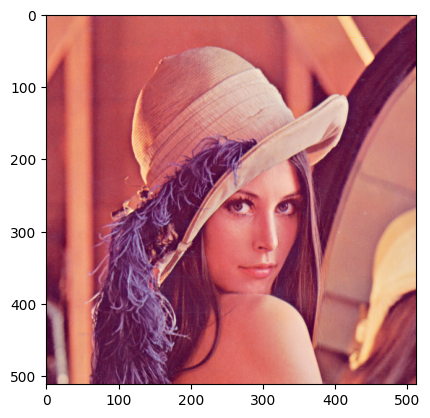

In [ ]:
# Loads the image from the specified file
image = cv2.imread("../img/lenna.png") # đọc ảnh lenna.png và lưu vào biến image, sử dụng hàm imread của thư viện OpenCV để đọc ảnh từ file
print(image) # in ra mảng dữ liệu của ảnh đã được đọc vào, mảng này chứa các giá trị màu sắc của từng pixel trong ảnh
# Converts the order of the color from BGR (Blue Green Red) to RGB (Red Green Blue) then renders the image from the array of data
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)) # chuyển đổi màu sắc của ảnh từ BGR (màu sắc mặc định của OpenCV) sang RGB (màu sắc chuẩn để hiển thị) và hiển thị ảnh đã được chuyển đổi bằng hàm imshow của thư viện matplotlib.pyplot

The images we are working with are comprised of RGB values which are values from 0 to 255. Zero means white noise, this makes the image look grainy:


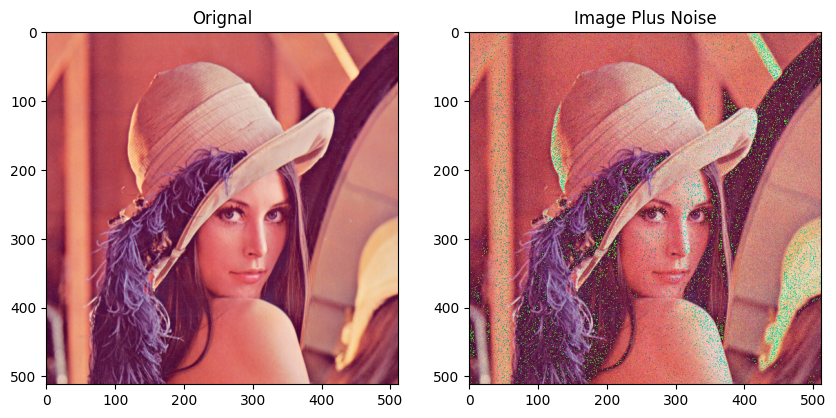

In [5]:
# Get the number of rows and columns in the image
rows, cols,_= image.shape # lấy số lượng hàng và cột của ảnh bằng cách truy cập thuộc tính shape của mảng dữ liệu ảnh, kết quả được lưu vào biến rows và cols, dấu _ được sử dụng để bỏ qua giá trị thứ ba (số kênh màu) vì nó không cần thiết cho việc tạo nhiễu
# Creates values using a normal distribution with a mean of 0 and standard deviation of 15, the values are converted to unit8 which means the values are between 0 and 255
noise = np.random.normal(0,15,(rows,cols,3)).astype(np.uint8) # tạo một mảng noise chứa các giá trị ngẫu nhiên được tạo ra từ phân phối chuẩn với trung bình là 0 và độ lệch chuẩn là 15, kích thước của mảng này là (rows, cols, 3) để phù hợp với kích thước của ảnh gốc, và sau đó chuyển đổi kiểu dữ liệu của mảng này sang uint8 để đảm bảo rằng các giá trị nằm trong khoảng từ 0 đến 255, phù hợp với định dạng màu sắc của ảnh
# Add the noise to the image
noisy_image = image + noise # cộng mảng noise vào mảng dữ liệu của ảnh gốc để tạo ra một ảnh mới có chứa nhiễu, kết quả được lưu vào biến noisy_image
# Plots the original image and the image with noise using the function defined at the top
plot_image(image, noisy_image, title_1="Orignal",title_2="Image Plus Noise") # sử dụng hàm plot_image đã được định nghĩa ở trên để hiển thị ảnh gốc và ảnh có chứa nhiễu cạnh nhau, với tiêu đề "Original" cho ảnh gốc và "Image Plus Noise" cho ảnh có chứa nhiễu

When adding noise to an image sometimes the value might be greater than 255, in this case, 256, is subtracted from the value to wrap the number around keeping it between 0 and 255. For example, consider an image with an RGB value of 137 and we add noise with an RGB value of 215 we get an RGB value of 352. We then subtract 256, the total number of possible values between 0 and 255, to get a number between 0 and 255.


### Filtering Noise


Smoothing filters average out the Pixels within a neighborhood, they are sometimes called low pass filters. For mean filtering, the  kernel simply averages out the kernels in a neighborhood.


In [7]:
# Create a kernel which is a 6 by 6 array where each value is 1/36
kernel = np.ones((6,6))/36 # tạo một kernel là một mảng 6x6, trong đó mỗi giá trị đều bằng 1/36, kernel này sẽ được sử dụng để làm mờ ảnh bằng cách lấy trung bình của các pixel lân cận

The function <code>filter2D</code> performs 2D convolution between the image <code>src</code> and the  <code>kernel</code> on each color channel independently. The parameter <a href="https://docs.opencv.org/master/d4/d86/group__imgproc__filter.html#filter_depths">ddepth</a> has to do with the size of the output image, we will set it to -1 so the input and output are the same size.


In [8]:
# Filters the images using the kernel
image_filtered = cv2.filter2D(src=noisy_image, ddepth=-1, kernel=kernel) # lọc ảnh noisy_image bằng cách sử dụng hàm filter2D của thư viện OpenCV, với tham số src là ảnh có chứa nhiễu, ddepth là -1 để giữ nguyên độ sâu của ảnh gốc, và kernel là kernel đã được tạo ra ở trên, kết quả được lưu vào biến image_filtered

We can plot the image before and after the filtering; we see the noise is reduced, but the image is blurry:


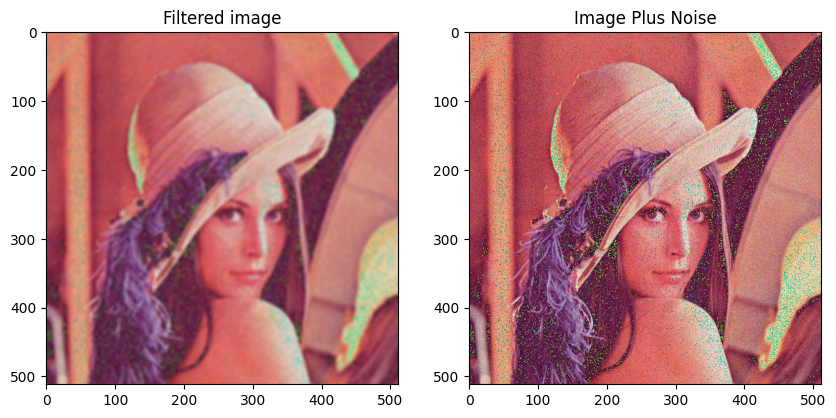

In [9]:
# Plots the Filtered and Image with Noise using the function defined at the top
plot_image(image_filtered, noisy_image,title_1="Filtered image",title_2="Image Plus Noise") # hiển thị ảnh đã được lọc và ảnh có nhiễu bằng cách sử dụng hàm plot_image đã được định nghĩa ở trên, với tiêu đề "Filtered image" cho ảnh đã được lọc và "Image Plus Noise" cho ảnh có nhiễu

A smaller kernel keeps the image sharp, but filters less noise, here we try a 4x4 kernel


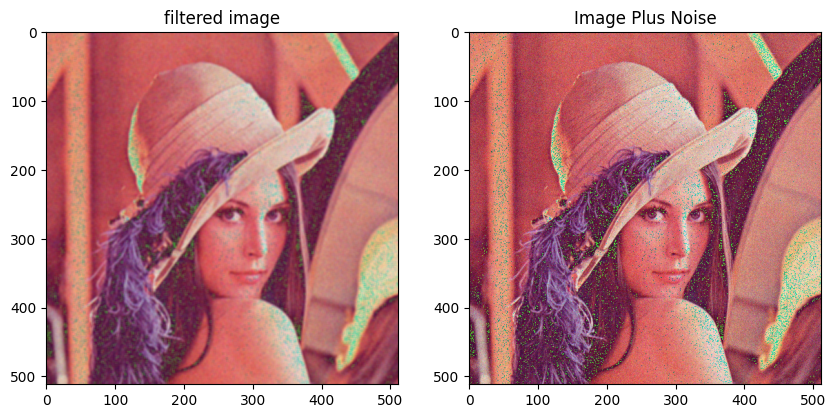

In [10]:
# Creates a kernel which is a 4 by 4 array where each value is 1/16
kernel = np.ones((4,4))/16 # tạo một kernel là một mảng 4x4, trong đó mỗi giá trị đều bằng 1/16, kernel này sẽ được sử dụng để làm mờ ảnh bằng cách lấy trung bình của các pixel lân cận, với kích thước nhỏ hơn so với kernel trước đó nên sẽ làm mờ ảnh ít hơn
# Filters the images using the kernel
image_filtered=cv2.filter2D(src=noisy_image,ddepth=-1,kernel=kernel) # lọc ảnh noisy_image bằng cách sử dụng hàm filter2D của thư viện OpenCV, với tham số src là ảnh có chứa nhiễu, ddepth là -1 để giữ nguyên độ sâu của ảnh gốc, và kernel là kernel đã được tạo ra ở trên, kết quả được lưu vào biến image_filtered
# Plots the Filtered and Image with Noise using the function defined at the top
plot_image(image_filtered , noisy_image,title_1="filtered image",title_2="Image Plus Noise") # hiển thị ảnh đã được lọc và ảnh có nhiễu bằng cách sử dụng hàm plot_image đã được định nghĩa ở trên, với tiêu đề "filtered image" cho ảnh đã được lọc và "Image Plus Noise" cho ảnh có nhiễu

### Gaussian Blur


The function  <code>GaussianBlur</code> convolves the source image with the specified Gaussian kernel It filters noise but does a better job of preserving the edges. It has the following parameters:


Parameters

<p><code>src</code> input image; the image can have any number of channels, which are processed independently</p>
<p><code>ksize:</code> Gaussian kernel size</p>
<p><code>sigmaX</code> Gaussian kernel standard deviation in the X direction</p>
<p><code>sigmaY</code> Gaussian kernel standard deviation in the Y direction; if sigmaY is zero, it is set to be equal to sigmaX </p>


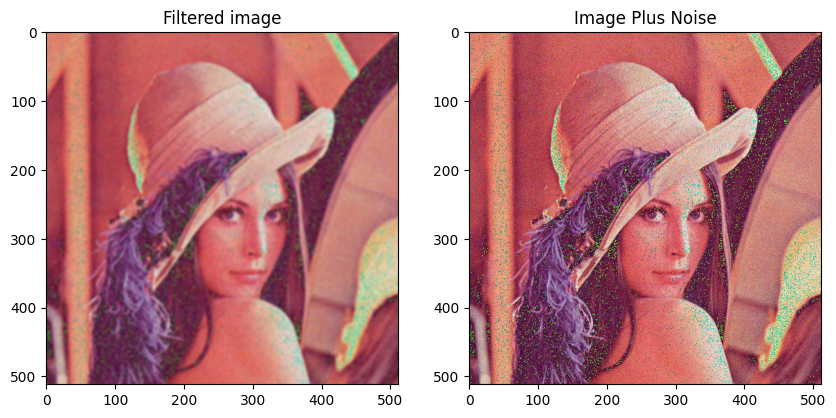

In [11]:
# Filters the images using GaussianBlur on the image with noise using a 4 by 4 kernel 
image_filtered = cv2.GaussianBlur(noisy_image,(5,5),sigmaX=4,sigmaY=4) # lọc ảnh noisy_image bằng cách sử dụng hàm GaussianBlur của thư viện OpenCV, với tham số src là ảnh có chứa nhiễu, (5,5) là kích thước của kernel Gaussian, sigmaX và sigmaY là độ lệch chuẩn của Gaussian theo chiều x và y, kết quả được lưu vào biến image_filtered
# Plots the Filtered Image then the Unfiltered Image with Noise
plot_image(image_filtered , noisy_image,title_1="Filtered image",title_2="Image Plus Noise") # hiển thị ảnh đã được lọc và ảnh có nhiễu bằng cách sử dụng hàm plot_image đã được định nghĩa ở trên, với tiêu đề "Filtered image" cho ảnh đã được lọc và "Image Plus Noise" cho ảnh có nhiễu

Sigma behaves like the size of the mean filter, a larger value of sigma will make the image blurry, but you are still constrained by the size of the filter, there we set sigma to 10


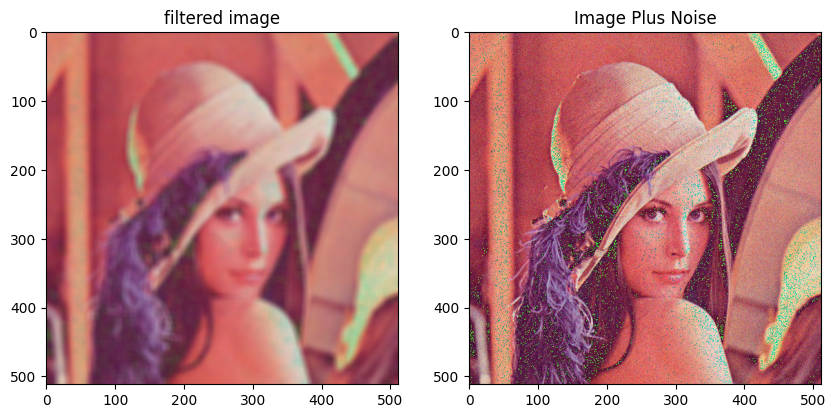

In [12]:
# Filters the images using GaussianBlur on the image with noise using a 11 by 11 kernel 
image_filtered = cv2.GaussianBlur(noisy_image,(11,11),sigmaX=10,sigmaY=10) # lọc ảnh noisy_image bằng cách sử dụng hàm GaussianBlur của thư viện OpenCV, với tham số src là ảnh có chứa nhiễu, (11,11) là kích thước của kernel Gaussian, sigmaX và sigmaY là độ lệch chuẩn của Gaussian theo chiều x và y, kết quả được lưu vào biến image_filtered
# Plots the Filtered Image then the Unfiltered Image with Noise
plot_image(image_filtered , noisy_image,title_1="filtered image",title_2="Image Plus Noise") # hiển thị ảnh đã được lọc và ảnh có nhiễu bằng cách sử dụng hàm plot_image đã được định nghĩa ở trên, với tiêu đề "filtered image" cho ảnh đã được lọc và "Image Plus Noise" cho ảnh có nhiễu

See what happens when you set different values of sigmaX, sigmaY, and or use  non-square kernels.


### Image Sharpening


Image Sharpening  involves smoothing the image and calculating the derivatives.  We can accomplish image sharpening by applying the following Kernel.


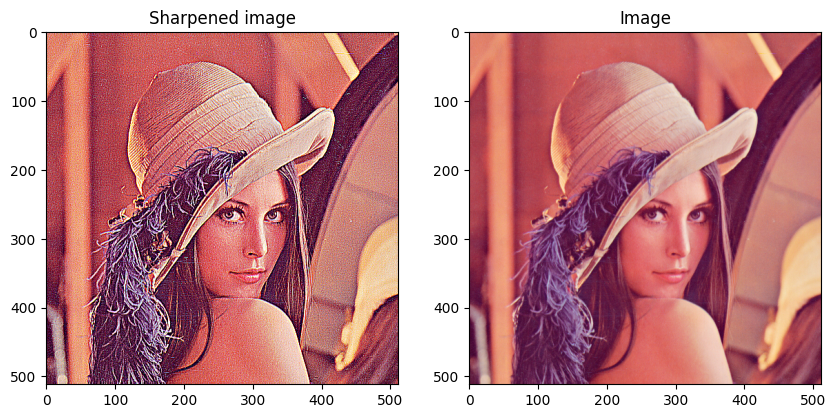

In [13]:
# Common Kernel for image sharpening
kernel = np.array([[-1,-1,-1], 
                   [-1, 9,-1],
                   [-1,-1,-1]]) # tạo một kernel là một mảng 3x3 với các giá trị được thiết kế để làm sắc nét ảnh, giá trị trung tâm là 9 và các giá trị xung quanh là -1, kernel này sẽ tăng cường độ tương phản của các pixel lân cận để làm cho ảnh trở nên sắc nét hơn
# Applys the sharpening filter using kernel on the original image without noise
sharpened = cv2.filter2D(image, -1, kernel) # áp dụng bộ lọc làm sắc nét bằng cách sử dụng hàm filter2D của thư viện OpenCV, với tham số src là ảnh gốc không có nhiễu, ddepth là -1 để giữ nguyên độ sâu của ảnh gốc, và kernel là kernel đã được tạo ra ở trên, kết quả được lưu vào biến sharpened
# Plots the sharpened image and the original image without noise
plot_image(sharpened , image, title_1="Sharpened image",title_2="Image") # hiển thị ảnh đã được làm sắc nét và ảnh gốc không có nhiễu bằng cách sử dụng hàm plot_image đã được định nghĩa ở trên, với tiêu đề "Sharpened image" cho ảnh đã được làm sắc nét và "Image" cho ảnh gốc không có nhiễu

## Edges


Edges are where pixel intensities change. The Gradient of a function outputs the rate of change; we can approximate the gradient of a grayscale image with convolution. There are several methods to approximate the gradient, let’s use the Sobel edge detector. This combines several convolutions and finding the magnitude of the result. Consider the following image:


[[181 201 202 ... 103 102  92]
 [171 198 201 ...  94  96  96]
 [175 195 193 ...  87  96  98]
 ...
 [100  97  97 ... 114 113 117]
 [ 94  97  99 ... 111 112 114]
 [ 96  95  98 ... 113 104 109]]


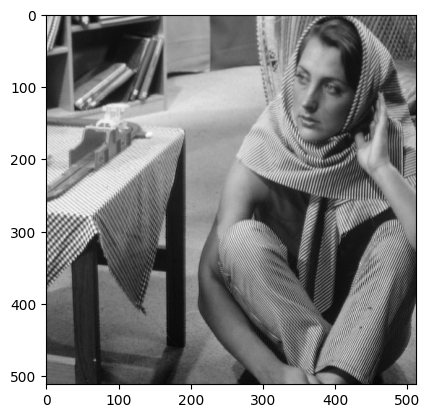

In [ ]:
# Loads the image from the specified file
img_gray = cv2.imread('../img/barbara.png', cv2.IMREAD_GRAYSCALE) # đọc ảnh barbara.png và lưu vào biến img_gray, sử dụng hàm imread của thư viện OpenCV để đọc ảnh từ file, với tham số cv2.IMREAD_GRAYSCALE để đọc ảnh ở chế độ xám (grayscale), kết quả là một mảng 2 chiều chứa các giá trị độ sáng của từng pixel trong ảnh
print(img_gray) # in ra mảng dữ liệu của ảnh đã được đọc vào, mảng này chứa các giá trị độ sáng của từng pixel trong ảnh, vì ảnh được đọc ở chế độ xám nên mảng này chỉ có 2 chiều (số hàng và số cột) thay vì 3 chiều như ảnh màu
# Renders the image from the array of data, notice how it is 2 diemensional instead of 3 diemensional because it has no color
plt.imshow(img_gray ,cmap='gray') # hiển thị ảnh đã được đọc vào bằng cách sử dụng hàm imshow của thư viện matplotlib.pyplot, với tham số cmap='gray' để hiển thị ảnh ở chế độ xám (grayscale), điều này giúp hiển thị đúng các giá trị độ sáng của ảnh mà không bị ảnh hưởng bởi màu sắc

We smooth the image, this decreases changes that may be caused by noise that would  affect the gradient.


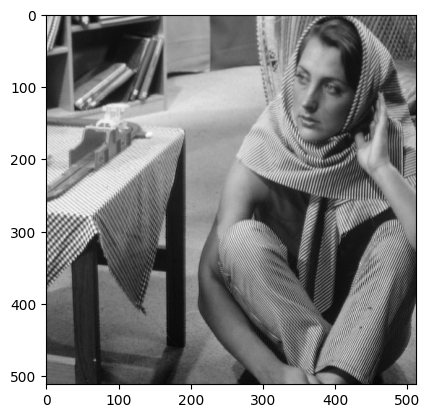

In [15]:
# Filters the images using GaussianBlur on the image with noise using a 3 by 3 kernel 
img_gray = cv2.GaussianBlur(img_gray,(3,3),sigmaX=0.1,sigmaY=0.1) # lọc ảnh img_gray bằng cách sử dụng hàm GaussianBlur của thư viện OpenCV, với tham số src là ảnh đã được đọc vào ở chế độ xám, (3,3) là kích thước của kernel Gaussian, sigmaX và sigmaY là độ lệch chuẩn của Gaussian theo chiều x và y, kết quả được lưu vào biến img_gray
# Renders the filtered image
plt.imshow(img_gray ,cmap='gray') # hiển thị ảnh đã được lọc bằng cách sử dụng hàm imshow của thư viện matplotlib.pyplot, với tham số cmap='gray' để hiển thị ảnh ở chế độ xám (grayscale), điều này giúp hiển thị đúng các giá trị độ sáng của ảnh mà không bị ảnh hưởng bởi màu sắc

We can approximate the derivative in the X or Y direction  using the <code>Sobel</code> function, here are the parameters:


<p><code>src</code>: input image</p>
<p><code>ddepth</code>: output image depth, see combinations; in the case of 8-bit input images it will result in truncated derivatives</p>
<p><code>dx</code>: order of the derivative x</p>
<p><code>dx</code>: order of the derivative y</p>
<p><code>ksize</code> size of the extended Sobel kernel; it must be 1, 3, 5, or 7</p>


dx = 1 represents the derivative in the x-direction.  The function approximates  the derivative by  convolving   the image with the following kernel  


\begin{bmatrix} 
1 & 0 & -1 \\\\\\
2 & 0 & -2 \\\\
1 & 0 & -1 
\end{bmatrix}


We can apply the function:


In [16]:
ddepth = cv2.CV_16S # đặt độ sâu của ảnh đầu ra là CV_16S, đây là một kiểu dữ liệu có thể chứa giá trị âm, điều này cần thiết khi sử dụng bộ lọc Sobel để phát hiện cạnh, vì kết quả của phép lọc này có thể bao gồm các giá trị âm do sự thay đổi độ sáng giữa các pixel
# Applys the filter on the image in the X direction
grad_x = cv2.Sobel(src=img_gray, ddepth=ddepth, dx=1, dy=0, ksize=3) # áp dụng bộ lọc Sobel để phát hiện cạnh theo hướng X bằng cách sử dụng hàm Sobel của thư viện OpenCV, với tham số src là ảnh đã được lọc ở chế độ xám, ddepth là độ sâu của ảnh đầu ra đã được đặt ở trên, dx=1 để chỉ định rằng chúng ta muốn phát hiện cạnh theo hướng X, dy=0 để không phát hiện cạnh theo hướng Y, và ksize=3 để sử dụng một kernel 3x3 cho phép lọc

We can plot the result 


In [ ]:
plt.imshow(grad_x,cmap='gray') # hiển thị ảnh grad_x bằng cách sử dụng hàm imshow của thư viện matplotlib.pyplot, với tham số cmap='gray' để hiển thị ảnh ở chế độ xám (grayscale), điều này giúp hiển thị đúng các giá trị độ sáng của ảnh mà không bị ảnh hưởng bởi màu sắc, ảnh grad_x chứa thông tin về các cạnh theo hướng X trong ảnh gốc sau khi đã được lọc bằng bộ lọc Sobel

dy=1 represents the derivative in the y-direction.  The function approximates  the derivative by  convolving   the image with the following kernel 


\begin{bmatrix} 
\ \ 1 & \ \ 2 & \ \ 1 \\\\\\
\ \ 0 & \ \ 0 & \ \ 0 \\\\
-1 & -2 & -1 
\end{bmatrix} 


We can apply the function and plot the result


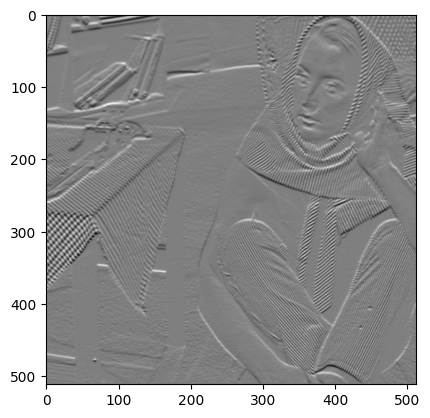

In [18]:
# Applys the filter on the image in the X direction
grad_y = cv2.Sobel(src=img_gray, ddepth=ddepth, dx=0, dy=1, ksize=3) # áp dụng bộ lọc Sobel để phát hiện cạnh theo hướng Y bằng cách sử dụng hàm Sobel của thư viện OpenCV, với tham số src là ảnh đã được lọc ở chế độ xám, ddepth là độ sâu của ảnh đầu ra đã được đặt ở trên, dx=0 để không phát hiện cạnh theo hướng X, dy=1 để chỉ định rằng chúng ta muốn phát hiện cạnh theo hướng Y, và ksize=3 để sử dụng một kernel 3x3 cho phép lọc
plt.imshow(grad_y,cmap='gray') # hiển thị ảnh grad_y bằng cách sử dụng hàm imshow của thư viện matplotlib.pyplot, với tham số cmap='gray' để hiển thị ảnh ở chế độ xám (grayscale), điều này giúp hiển thị đúng các giá trị độ sáng của ảnh mà không bị ảnh hưởng bởi màu sắc, ảnh grad_y chứa thông tin về các cạnh theo hướng Y trong ảnh gốc sau khi đã được lọc bằng bộ lọc Sobel

 We can approximate the  gradient by  calculating absolute values, and converts the result to 8-bit:


In [19]:
# Converts the values back to a number between 0 and 255
abs_grad_x = cv2.convertScaleAbs(grad_x) # chuyển đổi các giá trị trong ảnh grad_x trở lại thành các giá trị nằm trong khoảng từ 0 đến 255 bằng cách sử dụng hàm convertScaleAbs của thư viện OpenCV, hàm này sẽ lấy giá trị tuyệt đối của mỗi pixel trong grad_x và sau đó chuyển đổi nó sang kiểu dữ liệu uint8, kết quả được lưu vào biến abs_grad_x
abs_grad_y = cv2.convertScaleAbs(grad_y) # chuyển đổi các giá trị trong ảnh grad_y trở lại thành các giá trị nằm trong khoảng từ 0 đến 255 bằng cách sử dụng hàm convertScaleAbs của thư viện OpenCV, hàm này sẽ lấy giá trị tuyệt đối của mỗi pixel trong grad_y và sau đó chuyển đổi nó sang kiểu dữ liệu uint8, kết quả được lưu vào biến abs_grad_y

Then apply the  function <code>addWeighted</code> to  calculates the sum of two arrays as follows:


In [20]:
# Adds the derivative in the X and Y direction
grad = cv2.addWeighted(abs_grad_x, 0.5, abs_grad_y, 0.5, 0) # kết hợp hai ảnh abs_grad_x và abs_grad_y bằng cách sử dụng hàm addWeighted của thư viện OpenCV, với tham số src1 là ảnh abs_grad_x, alpha là hệ số trọng số cho ảnh abs_grad_x (0.5), src2 là ảnh abs_grad_y, beta là hệ số trọng số cho ảnh abs_grad_y (0.5), và gamma là giá trị được thêm vào kết quả cuối cùng (0), kết quả được lưu vào biến grad, ảnh grad sẽ chứa thông tin về các cạnh trong cả hai hướng X và Y

We then plot the results, we see the image with lines have high-intensity values representing a large  gradient   


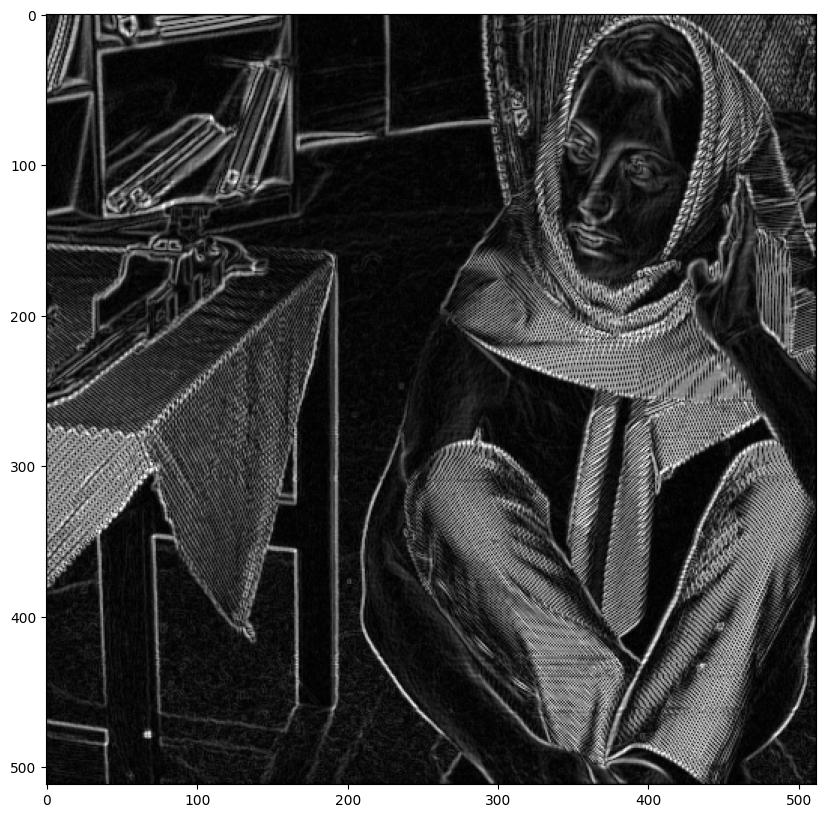

In [23]:
# Make the figure bigger and renders the image
plt.figure(figsize=(10,10)) # tạo một figure có kích thước 10x10 inch để hiển thị hình ảnh
plt.imshow(grad,cmap='gray') # hiển thị ảnh grad bằng cách sử dụng hàm imshow của thư viện matplotlib.pyplot, với tham số cmap='gray' để hiển thị ảnh ở chế độ xám (grayscale), điều này giúp hiển thị đúng các giá trị độ sáng của ảnh mà không bị ảnh hưởng bởi màu sắc, ảnh grad chứa thông tin về các cạnh trong cả hai hướng X và Y sau khi đã được kết hợp từ abs_grad_x và abs_grad_y

## Median

Median filters find the median of all the pixels under the kernel area and the central element is replaced with this median value. 


We can apply median filters to regular  images but let’s see how we can use  a median filter to improve segmentation.   Consider the cameraman example 


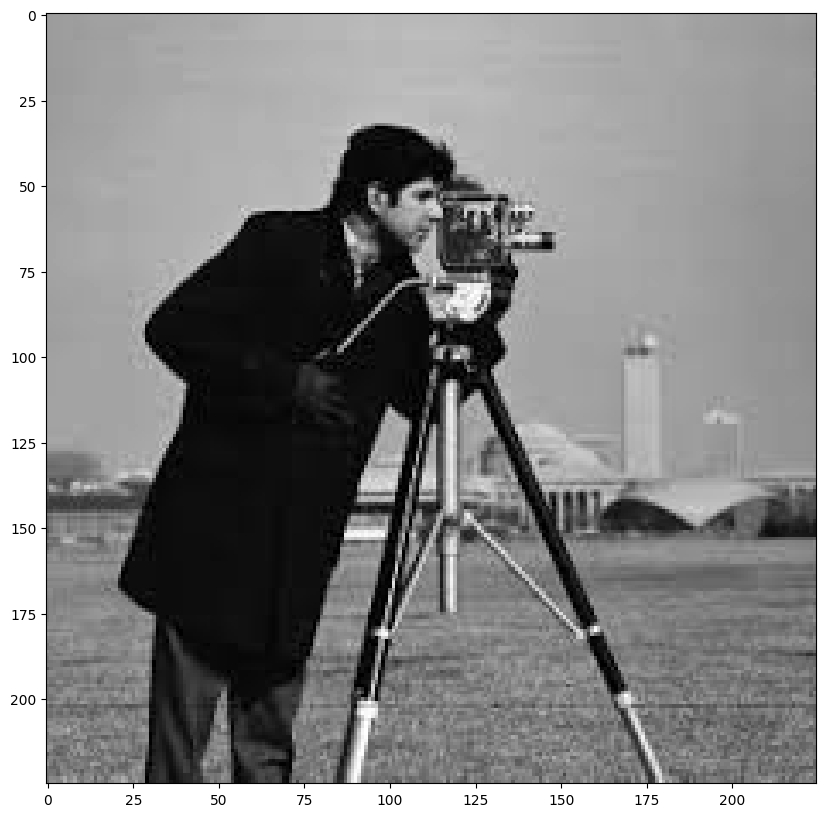

In [24]:
# Load the camera man image
image = cv2.imread("../img/cameraman.jpeg",cv2.IMREAD_GRAYSCALE) # đọc ảnh cameraman.jpeg và lưu vào biến image, sử dụng hàm imread của thư viện OpenCV để đọc ảnh từ file, với tham số cv2.IMREAD_GRAYSCALE để đọc ảnh ở chế độ xám (grayscale), kết quả là một mảng 2 chiều chứa các giá trị độ sáng của từng pixel trong ảnh
# Make the image larger when it renders
plt.figure(figsize=(10,10)) # tạo một figure có kích thước 10x10 inch để hiển thị hình ảnh
# Renders the image
plt.imshow(image,cmap="gray") # hiển thị ảnh đã được đọc vào bằng cách sử dụng hàm imshow của thư viện matplotlib.pyplot, với tham số cmap='gray' để hiển thị ảnh ở chế độ xám (grayscale), điều này giúp hiển thị đúng các giá trị độ sáng của ảnh mà không bị ảnh hưởng bởi màu sắc

Now let's apply a Median Filter by using the `medianBlur` function. The parameters for this function are `src`: The image and `ksize`: Kernel size


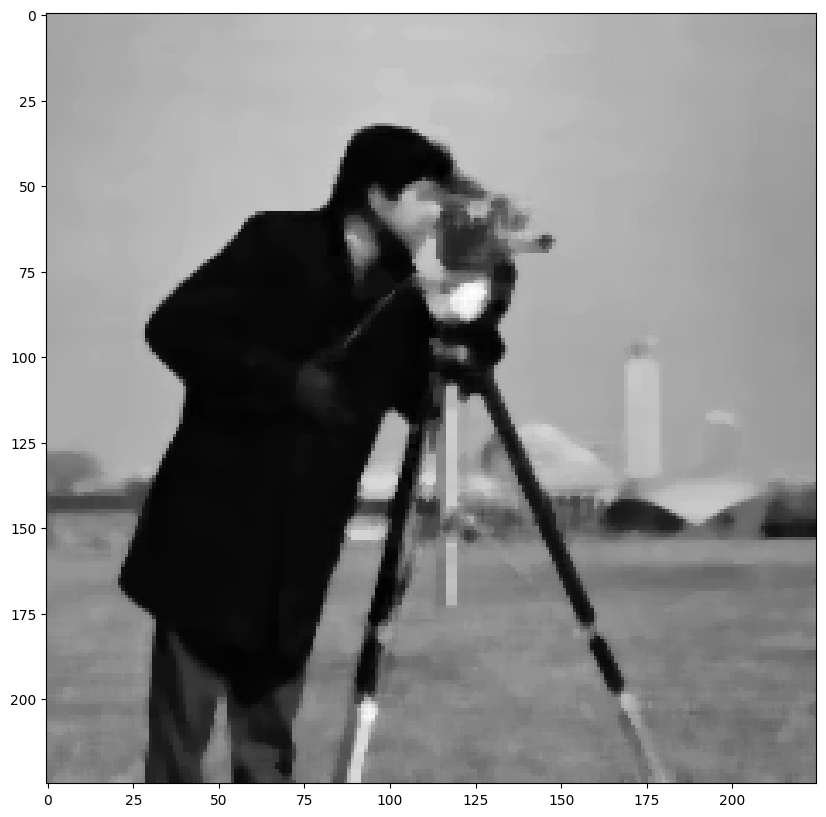

In [25]:
# Filter the image using Median Blur with a kernel of size 5
filtered_image = cv2.medianBlur(image, 5) # lọc ảnh image bằng cách sử dụng hàm medianBlur của thư viện OpenCV, với tham số src là ảnh đã được đọc vào ở chế độ xám, và 5 là kích thước của kernel (kích thước này phải là số lẻ), kết quả được lưu vào biến filtered_image, bộ lọc này sẽ thay thế mỗi pixel trong ảnh bằng giá trị trung vị của các pixel lân cận trong kernel, giúp loại bỏ nhiễu muối và tiêu
# Make the image larger when it renders
plt.figure(figsize=(10,10)) # tạo một figure có kích thước 10x10 inch để hiển thị hình ảnh
# Renders the image
plt.imshow(filtered_image,cmap="gray") # hiển thị ảnh đã được lọc bằng cách sử dụng hàm imshow của thư viện matplotlib.pyplot, với tham số cmap='gray' để hiển thị ảnh ở chế độ xám (grayscale), điều này giúp hiển thị đúng các giá trị độ sáng của ảnh mà không bị ảnh hưởng bởi màu sắc

We would like to find the cameraman, but median filtering captures some of the background.

## Threshold Function Parameters

`src`: The image to use
`thresh`: The threshold
`maxval`: The maxval to use
`type`: Type of filtering

The threshold function works by looking at each pixel's grayscale value and assigning a value if it is below the threshold and another value if it is above the threshold. In our example the threshold is 0 (black) and the type is binary inverse so if a value is above the threshold the assigned value is 0 (black) and if it is below or equals the threshold the maxval 255 (white) is used. So if the pixel is 0 black it is assigned 255 (white) and if the pixel is not black then it is assigned black which is what THRESH_BINARY_INV tells OpenCV to do. This is how it would work without THRESH_OTSU.

Since we are using THRESH_OTSU it means that OpenCV will decide an optimal threshold. In our example below the threshold, we provide does not get used in the filter OpenCV will use an optimal one.


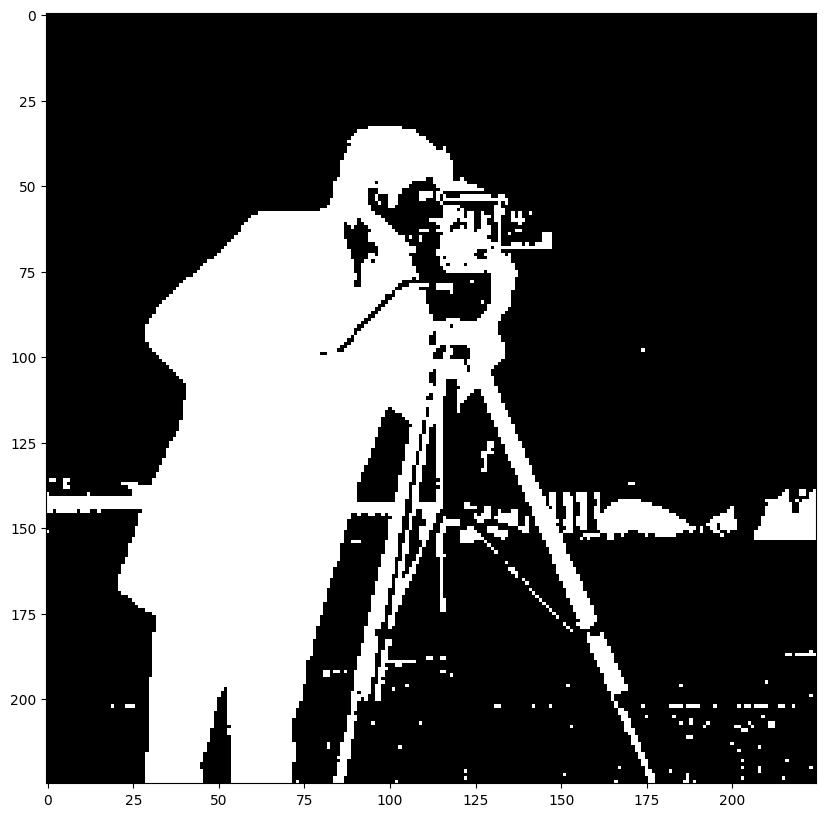

In [26]:
# Returns ret which is the threshold used and outs which is the image
ret, outs = cv2.threshold(src = image, thresh = 0, maxval = 255, type = cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV) # áp dụng ngưỡng Otsu để phân đoạn ảnh bằng cách sử dụng hàm threshold của thư viện OpenCV, với tham số src là ảnh đã được đọc vào ở chế độ xám, thresh là giá trị ngưỡng ban đầu (0 trong trường hợp này, nhưng sẽ bị bỏ qua vì chúng ta đang sử dụng Otsu), maxval là giá trị tối đa được gán cho các pixel vượt qua ngưỡng (255 trong trường hợp này), và type là loại ngưỡng được sử dụng (cv2.THRESH_OTSU để tự động tính toán ngưỡng tốt nhất và cv2.THRESH_BINARY_INV để tạo ra một ảnh nhị phân đảo ngược), kết quả trả về là ret (giá trị ngưỡng đã được tính toán) và outs (ảnh đã được phân đoạn)

# Make the image larger when it renders
plt.figure(figsize=(10,10)) # tạo một figure có kích thước 10x10 inch để hiển thị hình ảnh

# Render the image
plt.imshow(outs, cmap='gray') # hiển thị ảnh đã được phân đoạn bằng cách sử dụng hàm imshow của thư viện matplotlib.pyplot, với tham số cmap='gray' để hiển thị ảnh ở chế độ xám (grayscale), điều này giúp hiển thị đúng các giá trị độ sáng của ảnh mà không bị ảnh hưởng bởi màu sắc

Because those elements are mostly  zeros the median filter will filter out accordingly:  


# References


[1]  Images were taken from: [https://homepages.cae.wisc.edu/~ece533/images/](https://homepages.cae.wisc.edu/~ece533/images/?utm_email=Email&utm_source=Nurture&utm_content=000026UJ&utm_term=10006555&utm_campaign=PLACEHOLDER&utm_id=SkillsNetwork-Courses-IBMDeveloperSkillsNetwork-CV0101EN-Coursera-25797139)

[2]  <a href='https://pillow.readthedocs.io/en/stable/index.html'>Pillow Docs</a>

[3]  <a href='https://opencv.org/'>Open CV</a>

[4] Gonzalez, Rafael C., and Richard E. Woods. "Digital image processing." (2017).

[5 ] Jian, Wushuai, Xueyan Sun, and Shuqian Luo. "Computer-aided diagnosis of breast microcalcifications based on dual-tree complex wavelet transform." Biomedical engineering online 11.1 (2012): 1-12.
